We know this works on its own.

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path("~/Documents/vggt2/digitizing_reality/TRELLIS").expanduser()))

In [4]:
import os
# os.environ['ATTN_BACKEND'] = 'xformers'   # Can be 'flash-attn' or 'xformers', default is 'flash-attn'
os.environ['SPCONV_ALGO'] = 'native'        # Can be 'native' or 'auto', default is 'auto'.
                                            # 'auto' is faster but will do benchmarking at the beginning.
                                            # Recommended to set to 'native' if run only once.

import imageio
from PIL import Image
from trellis.pipelines import TrellisImageTo3DPipeline
from trellis.utils import render_utils, postprocessing_utils
from matplotlib import pyplot as plt

In [3]:
# Load a pipeline from a model folder or a Hugging Face model hub.
pipeline = TrellisImageTo3DPipeline.from_pretrained("microsoft/TRELLIS-image-large")
pipeline.cuda()

[SPARSE][CONV] spconv algo: native
[ATTENTION] Using backend: flash_attn


/home/ahc/miniconda3/envs/reconviagen/lib/python3.10/site-packages/spconv/pytorch/functional.py:47: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  _TORCH_CUSTOM_FWD = amp.custom_fwd(cast_inputs=torch.float16)
/home/ahc/miniconda3/envs/reconviagen/lib/python3.10/site-packages/spconv/pytorch/functional.py:97: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, grad_output):
/home/ahc/miniconda3/envs/reconviagen/lib/python3.10/site-packages/spconv/pytorch/functional.py:163: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, grad_output):
/home/ahc/miniconda3/envs/reconviagen/lib/python3.10/site-packages/spconv/pytorch/functional.py:243: FutureWarning: `torch.cuda.amp.custom_bwd(args...

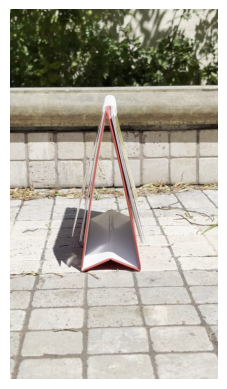

In [8]:
image = Image.open("./data/frame_B0.jpg")
plt.axis("off")
plt.imshow(image)

In [9]:
outputs = pipeline.run(
    image,
    seed=1,
    # Optional parameters
    # sparse_structure_sampler_params={
    #     "steps": 12,
    #     "cfg_strength": 7.5,
    # },
    # slat_sampler_params={
    #     "steps": 12,
    #     "cfg_strength": 3,
    # },
)

Sampling: 100%|██████████| 25/25 [00:04<00:00,  5.89it/s]


In [10]:
video = render_utils.render_video(outputs['gaussian'][0])['color']
imageio.mimsave("./data/eval/TRELLIS_gs.gif", video, fps=30, loop=0)

Rendering: 300it [00:00, 335.08it/s]
